Text(0, 0.5, 'Doppler b parameter (km/s)')

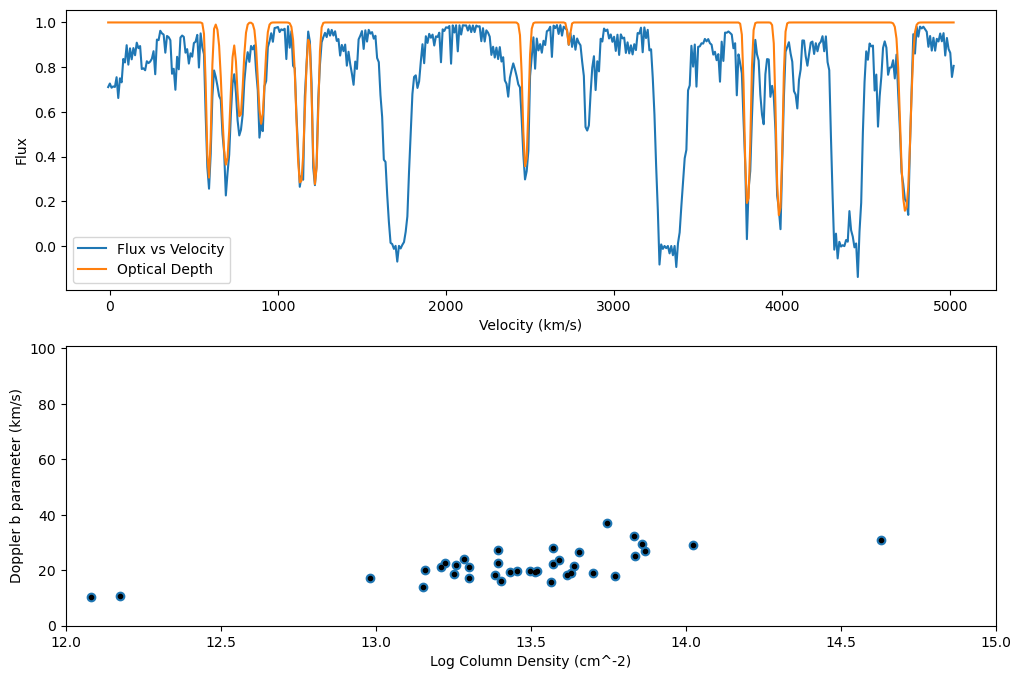

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import stats
import math

filename = "los-Copy1.00000.fHI"
vel1,flux1 = np.loadtxt(filename,delimiter = ',', unpack = True, skiprows = 2)
vel = []
flux = []
for i in range(504):
    vel.append(vel1[i])
    flux.append(flux1[i])
fig, axs = plt.subplots(2,figsize = (12,8))
axs[0].plot(vel, flux, label = 'Flux vs Velocity')
axs[0].set_ylabel('Flux')
axs[0].set_xlabel('Velocity (km/s)')

filename = "los.00000 (1).bN"
WL, ro, b, dWL, dro, db, chisq = np.loadtxt(filename, unpack = True)

WL1 = []
ro1 = []
dWL1 = []
dro1 = []
db1 = []
b1 = []
chisq1 = []

for i in range(len(chisq)):
    if 0.1 < chisq[i] < 3  and 8 < b[i] < 100 and 12 < ro[i] < 15 and np.isfinite(chisq[i]) and np.isfinite(db[i]) and np.isfinite(dro[i]) and np.isfinite(ro[i]) and np.isfinite(b[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])   
     
Cm = 4.5e-18
c = 3e5
vi_lst = []
for i in WL1:
    vi = 3e5 * ((i / (4*1216)) - 1)
    vi_lst.append(vi)   
def tfit(num):
    sum1 = 0
    for i in range(len(WL1)):
        A = (10**ro1[i] * c) / (b1[i] * np.sqrt(np.pi))
        B = ((num - vi_lst[i]) ** 2) / (b1[i] ** 2)
        sum1 += A * np.exp(-B)
    val = Cm * sum1
    return val  

axs[0].plot(vel,np.exp(-tfit(vel)), label = 'Optical Depth')
axs[0].legend()

axs[1].errorbar(ro1, b1, dro1, fmt = 'k.', label = 'Errors',capsize = 0)
axs[1].plot(ro1, b1, 'o')
axs[1].set_xlim(12,15)
axs[1].set_ylim(0,101)
axs[1].set_xlabel('Log Column Density (cm^-2)')
axs[1].set_ylabel('Doppler b parameter (km/s)')


In [2]:
# Part B
import scipy
# Conversion of Log10(N) to Ln(N)
x = np.array(ro1) * np.log(10)
dx = np.array(dro1) * np.log(10)
N0 = 3e13
xmax = np.log(1.0e15)
xmin = np.log(1.0e12)

def ifun2(x,b,t,bi,xi,dbi,dxi):
    bt = t[0]* ((np.exp(x)/N0)**t[1])
    bstar = bt* (t[3]/t[4])**(1/t[4])
    p = (t[4] * np.exp(x * t[2]) * ((bstar/b)**t[3]) * np.exp(-(bstar/b)**t[4]) ) / ( bstar * scipy.special.gamma((t[3]-1)/t[4]))
    v = np.exp(- ((b - bi) ** 2) / (2 * (dbi ** 2)) ) 
    v1 = np.exp(- ((x - xi) **2) / (2 * (dxi ** 2)) )
    num = p * v * v1
    return num
             
def llfun2(t):
    ret = 0
    if(t[2] == 0):
        fact0 = 1/(xmax-xmin)
    else:
        fact0 = t[2]/(np.exp(t[2]*xmax)-np.exp(t[2]*xmin))
    for i in range(len(x)):
        C1 = (2 * np.pi * dx[i] * db1[i])
        fact = fact0 / C1
        b_lim = [max(0, b1[i] - 5*db1[i]), b1[i] + 5*db1[i]]
        x_lim = [max(xmin, x[i] - 5*dx[i]), min(xmax, x[i] + 5*dx[i])]
        v = scipy.integrate.dblquad(ifun2,b_lim[0],b_lim[1],x_lim[0],x_lim[1],args=(t,b1[i],x[i],db1[i],dx[i]))
        if(v[0] > 0): 
            ret -= np.log(fact * v[0])
    print(t,ret)
    return ret

't = [b0, β, α, ϕ, Φ]'
t0 = [15, 0.2, 0.2, 3, 3]

print(llfun2(t0))

[15, 0.2, 0.2, 3, 3] 203.98529654343253
203.98529654343253


In [3]:
# Part C
from timeit import default_timer as timer # time all methods
start_time = timer()
't = [b0, β, α, ϕ, Φ]'
t0 = [19.14870967,  0.19073111, -0.02311224,  8.0,          5.27297551]
bounds0 = scipy.optimize.Bounds()
bounds0.lb = np.array([3, -1, -1, 2, 0.5])
bounds0.ub = np.array([50, 2,  1, 8, 6])
res = scipy.optimize.minimize(llfun2, t0, bounds = bounds0)
print("optimization time=%g"%(timer()-start_time))
print(res)
# [19.14870967  0.19073111 -0.02311224  8.          5.27297551] 176.9088095470925

[19.14870967  0.19073111 -0.02311224  8.          5.27297551] 176.90880954709138
[19.14870968  0.19073111 -0.02311224  8.          5.27297551] 176.90880954709002
[19.14870967  0.19073112 -0.02311224  8.          5.27297551] 176.90880954705628
[19.14870967  0.19073111 -0.02311223  8.          5.27297551] 176.90880954712404
[19.14870967  0.19073111 -0.02311224  7.99999999  5.27297551] 176.90880955019816
[19.14870967  0.19073111 -0.02311224  8.          5.27297552] 176.9088095470673
[19.14884609  0.19424119 -0.02637789  8.          5.27538283] 176.91863045400964
[19.1488461   0.19424119 -0.02637789  8.          5.27538283] 176.918630453944
[19.14884609  0.1942412  -0.02637789  8.          5.27538283] 176.91863050527522
[19.14884609  0.19424119 -0.02637788  8.          5.27538283] 176.918630449106
[19.14884609  0.19424119 -0.02637789  7.99999999  5.27538283] 176.91863045709542
[19.14884609  0.19424119 -0.02637789  8.          5.27538284] 176.91863045409272
[19.14870987  0.19073621 -0.02311

In [4]:
't = [b0, β, α, ϕ, Φ]'
b0_star = res.x[0]
beta_star = res.x[1]
B_pair = (b0_star, beta_star)

bb = 1 + 1.4*beta_star
G = ((3.634 * beta_star) / bb) + 1
T = (( (b0_star / 13) ** 2) * (bb / 1 + 0.128*beta_star) ** beta_star ) ** (1 / bb)
C_pair = (T, G - 1 )
print(B_pair)
print(C_pair)

(19.14870986832592, 0.19073621276111663)
(1.9152158659599539, 0.5470549358761017)


[-0.02311699  8.          5.27297901] 185.46713466111547
[-0.02311698  8.          5.27297901] 185.46713466087473
[-0.02311699  7.99999999  5.27297901] 185.46713464831925
[-0.02311699  8.          5.27297902] 185.46713466503022
[9.56200456e-04 6.72037790e+00 4.88150407e+00] 184.40162701076358
[9.56210456e-04 6.72037790e+00 4.88150407e+00] 184.4016270469857
[9.56200456e-04 6.72037791e+00 4.88150407e+00] 184.40162701410847
[9.56200456e-04 6.72037790e+00 4.88150408e+00] 184.40162700872048
[-0.41585897  5.1209751   4.42996582] 196.32224802199977
[-0.41585896  5.1209751   4.42996582] 196.32224750150297
[-0.41585897  5.12097511  4.42996582] 196.32224800615495
[-0.41585897  5.1209751   4.42996583] 196.32224801142377
[-0.02644055  6.61525112  4.85182501] 184.33558097132536
[-0.02644054  6.61525112  4.85182501] 184.33558096622232
[-0.02644055  6.61525113  4.85182501] 184.3355809737338
[-0.02644055  6.61525112  4.85182502] 184.33558096876072
[-0.02252173  6.43216936  4.79857501] 184.322382777340

[-0.02628993  6.41080654  4.65193145] 184.42837475976543
[-0.02281196  6.50265224  4.68987254] 184.42243517535536
[-0.02281195  6.50265224  4.68987254] 184.42243517516863
[-0.02281196  6.50265225  4.68987254] 184.42243517641285
[-0.02281196  6.50265224  4.68987255] 184.42243517288105
[-0.02232276  6.49216584  4.69858026] 184.41919573016884
[-0.02232275  6.49216584  4.69858026] 184.41919573072104
[-0.02232276  6.49216585  4.69858026] 184.4191957311798
[-0.02232276  6.49216584  4.69858027] 184.41919572767327
[-0.02036594  6.45022023  4.73341114] 184.40691008166897
[-0.02036593  6.45022023  4.73341114] 184.40691008517723
[-0.02036594  6.45022024  4.73341114] 184.4069100824889
[-0.02036594  6.45022023  4.73341115] 184.4069100790885
[-1.90855840e-03  5.72813046e+00  5.60922264e+00] 184.2337347756578
[-1.90854840e-03  5.72813046e+00  5.60922264e+00] 184.23373480710666
[-1.90855840e-03  5.72813047e+00  5.60922264e+00] 184.23373477284665
[-1.90855840e-03  5.72813046e+00  5.60922265e+00] 184.23

[-0.16781573  8.          3.69174887] 180.91874780422017
[-0.02751586  8.          4.55637987] 179.12170859116068
[-0.02751585  8.          4.55637987] 179.12170858438373
[-0.02751586  7.99999999  4.55637987] 179.1217085943195
[-0.02751586  8.          4.55637988] 179.12170859229292
[-0.0224888   8.          4.39283339] 179.11248428621315
[-0.02248879  8.          4.39283339] 179.11248428701433
[-0.0224888   7.99999999  4.39283339] 179.11248429010237
[-0.0224888  8.         4.3928334] 179.11248428600967
[-0.02301865  8.          4.41775597] 179.1122177719142
[-0.02301864  8.          4.41775597] 179.1122177719164
[-0.02301865  7.99999999  4.41775597] 179.1122177756917
[-0.02301865  8.          4.41775598] 179.11221777192046
[-0.02302027  8.          4.41701227] 179.11221753965373
[-0.02302026  8.          4.41701227] 179.11221753965347
[-0.02302027  7.99999999  4.41701227] 179.11221754343458
[-0.02302027  8.          4.41701228] 179.11221753965376
5- parameter Min Liklihood value 176.9

[-0.14689922  7.35039909  0.96804497] 198.2375541575325
[-0.14689921  7.35039909  0.96804497] 198.2375539749807
[-0.14689922  7.3503991   0.96804497] 198.23755412886015
[-0.14689922  7.35039909  0.96804498] 198.23755398349385
[-0.07517567  7.72679951  3.46246727] 184.39683150897903
[-0.07517566  7.72679951  3.46246727] 184.3968314316131
[-0.07517567  7.72679952  3.46246727] 184.39683150013775
[-0.07517567  7.72679951  3.46246728] 184.39683151497454
[0.67201707 7.57875432 1.81962895] 219.63191132507234
[0.67201708 7.57875432 1.81962895] 219.63191213213517
[0.67201707 7.57875433 1.81962895] 219.63191130428993
[0.67201707 7.57875432 1.81962896] 219.63191126717507
[-0.02367535  7.71659549  3.34923452] 184.15397315012117
[-0.02367534  7.71659549  3.34923452] 184.15397314999115
[-0.02367535  7.7165955   3.34923452] 184.15397314043346
[-0.02367535  7.71659549  3.34923453] 184.15397315335457
[-0.02318387  7.7120462   3.26518327] 184.14018078907074
[-0.02318386  7.7120462   3.26518327] 184.1401

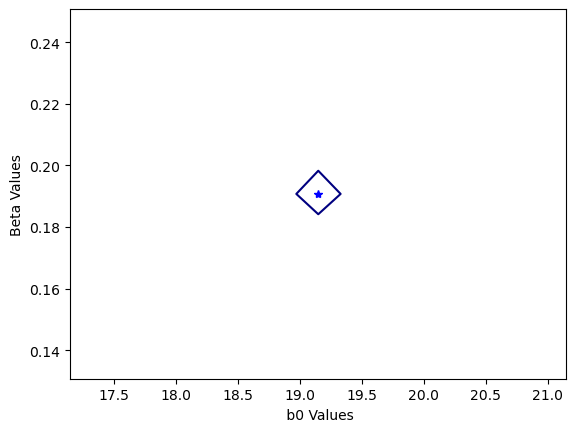

In [5]:
# Part D

def ifun(x,b,t,B0,BE,bi,xi,dbi,dxi):
    bt = B0 * ((np.exp(x)/N0) ** BE)
    bstar = bt * (t[1]/t[2])**(1/t[2])
    p = (t[2] * np.exp(x * t[0]) * ((bstar/b)**t[1]) * np.exp(-(bstar/b)**t[2]) ) / ( bstar * scipy.special.gamma((t[1]-1)/t[2]))
    v = np.exp(- ((b - bi) ** 2) / (2 * (dbi ** 2)) ) 
    v1 = np.exp(- ((x - xi) **2) / (2 * (dxi ** 2)) )
    num = p * v * v1
    return num           
def llfun(t,B0,BE):
    ret = 0
    if(t[0] == 0):
        fact0 = 1/(xmax-xmin)
    else:
        fact0 = t[0]/(np.exp(t[0]*xmax)-np.exp(t[0]*xmin))
    for i in range(len(x)):
        C1 = (2 * np.pi * dx[i] * db1[i])
        fact = fact0 / C1
        b_lim = [max(0, b1[i] - 5 * db1[i]), b1[i] + 5*db1[i]]
        x_lim = [max(xmin, x[i] - 5*dx[i]), min(xmax, x[i] + 5*dx[i])]
        v = scipy.integrate.dblquad(ifun,b_lim[0],b_lim[1],x_lim[0],x_lim[1],args=(t,B0,BE,b1[i],x[i],db1[i],dx[i]))
        if(v[0] > 0): 
            ret -= np.log(fact * v[0])
    print(t,ret)
    return ret

b01 =  res.x[0]
db0 = 4
b11 = res.x[1]
db11 = 0.12
N = 2
tv = [1,1]
#t = [α, ϕ, Φ]
p1 = [res.x[2], res.x[3], res.x[4]]

b0vals = np.zeros(( N + 1,N + 1))
Bvals = np.zeros((  N + 1,N + 1))
pvals = np.zeros((  N + 1,N + 1))

bounds0 = scipy.optimize.Bounds()
bounds0.lb = np.array([-1, 2, 0.5])
bounds0.ub = np.array([1, 8, 6])
for i1 in range(N + 1):
    tv[0] = b01 + (db0/N) * (i1 - N/2)
    for i0 in range(N + 1):
        tv[1] = b11  + (db11/N) * (i0 - N/2)
        b0vals[i0,i1] = tv[0]
        Bvals[i0,i1] =  tv[1] 
        resmin = scipy.optimize.minimize(llfun, p1, args = (tv[0],tv[1]), bounds = bounds0)
        chisqq = resmin.fun - res.fun
        pvals[i0,i1] =  1 - scipy.stats.chi2.cdf(chisqq, 2)
        print('5- parameter Min Liklihood value',res.fun)
        print('3-parameter Likelihood Value',resmin.fun)
        print('Chisquare value',chisqq)
        print('B0 Values',b0vals)
        print('Beta Values',Bvals)
        print('P Values',pvals)
        
fig, ax = plt.subplots()
ax.set_ylabel("Beta Values")
ax.set_xlabel(" b0 Values")
ax.contour(b0vals, Bvals, pvals, levels=[0.5*scipy.stats.chi2.ppf(0.60, 2),0.5*scipy.stats.chi2.ppf(0.90, 2)], colors = "#000080")
ax.plot([res.x[0]],[res.x[1]],"b*")
  
        

B0 Values [[17.14870987 19.14870987 21.14870987]
 [17.14870987 19.14870987 21.14870987]
 [17.14870987 19.14870987 21.14870987]]
Beta Values [[0.13073621 0.13073621 0.13073621]
 [0.19073621 0.19073621 0.19073621]
 [0.25073621 0.25073621 0.25073621]]
P Values [[0.0301155  0.23840092 0.01610774]
 [0.05489836 1.         0.07119668]
 [0.02777811 0.33230435 0.03117089]]


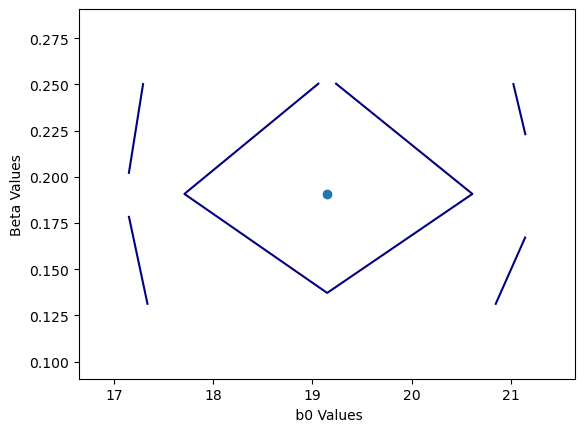

In [56]:
print('B0 Values',b0vals)
print('Beta Values',Bvals)
print('P Values',pvals)
fig, ax = plt.subplots()
ax.set_ylabel("Beta Values")
ax.set_xlabel(" b0 Values")

#ax.set_xlim(res.x[0]-0.5,res.x[0]+0.5)
#ax.set_ylim(0.18,0.20)
ax.set_xlim(res.x[0]-2.5,res.x[0]+2.5)
ax.set_ylim(res.x[1]-0.1,res.x[1]+0.1)
ax.contour(b0vals, Bvals, pvals, levels=[0.05,0.32], colors = "#000080")
ax.plot([res.x[0]],[res.x[1]],"o")

[[0.40159177 0.40159177 0.40159177]
 [0.54705494 0.54705494 0.54705494]
 [0.67442983 0.67442983 0.67442983]]
[[1.62965894 1.96376184 2.32288396]
 [1.60914489 1.91521587 2.24037559]
 [1.60033516 1.88422045 2.18273253]]
(1.9152158659599539, 0.5470549358761017)


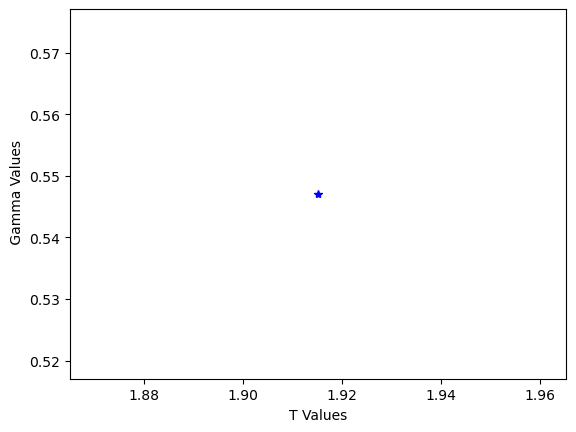

In [57]:
Gvals = np.zeros(( N + 1,N + 1))
Tvals = np.zeros((  N + 1,N + 1))
for i1 in range(N+1):
    for i2 in range (N+1):
        bb = 1 + 1.4*Bvals[i1][i2]
        G = ((3.634 * Bvals[i1][i2]) / bb) 
        T = (( (b0vals[i1][i2] / 13) ** 2) * (bb / 1 + 0.128* Bvals[i1][i2]) ** Bvals[i1][i2] ) ** (1 / bb)
        Gvals[i1][i2] = G 
        Tvals[i1][i2] = T
print(Gvals)
print(Tvals)
print(C_pair)
fig, ax = plt.subplots()
ax.set_xlabel("T Values")
ax.set_ylabel(" Gamma Values")
ax.set_xlim(C_pair[0] - 0.05,C_pair[0] + 0.05)
ax.set_ylim(C_pair[1] - 0.03,C_pair[1] + 0.03)
ax.contour(Tvals, Gvals, pvals, levels=[0.05, 0.32], colors = "#000080")
ax.plot([C_pair[0]],[C_pair[1]],"b*")

[-0.02311699  8.          5.27297901] 194.57653640288612
[-0.02311698  8.          5.27297901] 194.57653640302715
[-0.02311699  7.99999999  5.27297901] 194.57653637773356
[-0.02311699  8.          5.27297902] 194.57653642170771
[-0.03721984  5.48474407  3.3908195 ] 190.37740276824522
[-0.03721983  5.48474407  3.3908195 ] 190.37740274723154
[-0.03721984  5.48474408  3.3908195 ] 190.37740276114985
[-0.03721984  5.48474407  3.39081951] 190.377402762046
[0.94306812 5.64235627 3.55031004] 245.99172730404663
[0.94306813 5.64235627 3.55031004] 245.99172825122798
[0.94306812 5.64235628 3.55031004] 245.99172730001072
[0.94306812 5.64235627 3.55031005] 245.991727300507
[-0.02298799  5.48703229  3.39313499] 190.3596966941463
[-0.02298798  5.48703229  3.39313499] 190.35969669456986
[-0.02298799  5.4870323   3.39313499] 190.35969668709657
[-0.02298799  5.48703229  3.393135  ] 190.35969668798768
[-0.02389134  6.06187449  3.82376059] 190.1432277752496
[-0.02389133  6.06187449  3.82376059] 190.1432277

[0.1188324  5.70619751 3.97767665] 190.63585985432732
[0.1188324  5.7061975  3.97767666] 190.63585985309527
[-0.15849046  5.04196144  3.60542117] 191.17882620253005
[-0.15849045  5.04196144  3.60542117] 191.1788260023626
[-0.15849046  5.04196145  3.60542117] 191.17882618983592
[-0.15849046  5.04196144  3.60542118] 191.17882619303683
[-0.00766779  5.40320774  3.80787316] 189.3331602041754
[-0.00766778  5.40320774  3.80787316] 189.33316022692318
[-0.00766779  5.40320775  3.80787316] 189.33316019794367
[-0.00766779  5.40320774  3.80787317] 189.33316019853774
[-0.02872552  6.02147435  4.15824272] 189.13518482891692
[-0.02872551  6.02147435  4.15824272] 189.1351848196997
[-0.02872552  6.02147436  4.15824272] 189.1351848319056
[-0.02872552  6.02147435  4.15824273] 189.1351848289926
[-0.02265435  5.86517219  4.08242423] 189.1058974650273
[-0.02265434  5.86517219  4.08242423] 189.10589746501074
[-0.02265435  5.8651722   4.08242423] 189.10589746595542
[-0.02265435  5.86517219  4.08242424] 189.1

[-0.01591207  7.06150662  2.67824177] 185.3651961787772
[-0.01591208  7.06150663  2.67824177] 185.36519615501135
[-0.01591208  7.06150662  2.67824178] 185.36519615028402
[-0.34600263  7.60865534  3.64489968] 191.88027312355644
[-0.34600262  7.60865534  3.64489968] 191.88027267982682
[-0.34600263  7.60865535  3.64489968] 191.88027312042067
[-0.34600263  7.60865534  3.64489969] 191.88027312840848
[-0.06179075  7.13755379  2.81259573] 185.17109415687048
[-0.06179074  7.13755379  2.81259573] 185.17109409872995
[-0.06179075  7.1375538   2.81259573] 185.17109414539166
[-0.06179075  7.13755379  2.81259574] 185.17109414316485
[-6.44935405e-03  7.45149243e+00  3.68426405e+00] 184.49497806800278
[-6.44934405e-03  7.45149243e+00  3.68426405e+00] 184.49497809303577
[-6.44935405e-03  7.45149244e+00  3.68426405e+00] 184.494978064227
[-6.44935405e-03  7.45149243e+00  3.68426406e+00] 184.49497807238362
[-0.02441406  7.43098274  3.5534224 ] 184.43917480857775
[-0.02441405  7.43098274  3.5534224 ] 184.4

[0.60875967 7.6151173  1.86263758] 214.81518283682598
[0.60875968 7.6151173  1.86263758] 214.81518359948413
[0.60875967 7.61511731 1.86263758] 214.8151828161124
[0.60875967 7.6151173  1.86263759] 214.81518278067827
[-0.02431523  7.741692    3.35597844] 184.41412816153348
[-0.02431522  7.741692    3.35597844] 184.41412816055865
[-0.02431523  7.74169201  3.35597844] 184.4141281514103
[-0.02431523  7.741692    3.35597845] 184.41412816420484
[-0.02315827  7.74165821  3.29538963] 184.40253142043582
[-0.02315826  7.74165821  3.29538963] 184.4025314211939
[-0.02315827  7.74165822  3.29538963] 184.402531409894
[-0.02315827  7.74165821  3.29538964] 184.4025314215941
[-0.02245225  7.92255566  3.20058385] 184.20883840667972
[-0.02245224  7.92255566  3.20058385] 184.20883840848978
[-0.02245225  7.92255567  3.20058385] 184.20883839638137
[-0.02245225  7.92255566  3.20058386] 184.20883840663365
[-0.02215     8.          3.15999637] 184.13079494358254
[-0.02214999  8.          3.15999637] 184.1307949

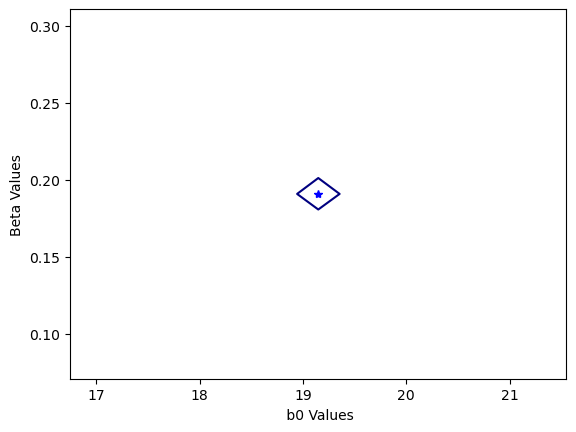

In [58]:
# Part D

def ifun(x,b,t,B0,BE,bi,xi,dbi,dxi):
    bt = B0 * ((np.exp(x)/N0) ** BE)
    bstar = bt * (t[1]/t[2])**(1/t[2])
    p = (t[2] * np.exp(x * t[0]) * ((bstar/b)**t[1]) * np.exp(-(bstar/b)**t[2]) ) / ( bstar * scipy.special.gamma((t[1]-1)/t[2]))
    v = np.exp(- ((b - bi) ** 2) / (2 * (dbi ** 2)) ) 
    v1 = np.exp(- ((x - xi) **2) / (2 * (dxi ** 2)) )
    num = p * v * v1
    return num           
def llfun(t,B0,BE):
    ret = 0
    if(t[0] == 0):
        fact0 = 1/(xmax-xmin)
    else:
        fact0 = t[0]/(np.exp(t[0]*xmax)-np.exp(t[0]*xmin))
    for i in range(len(x)):
        C1 = (2 * np.pi * dx[i] * db1[i])
        fact = fact0 / C1
        b_lim = [max(0, b1[i] - 5 * db1[i]), b1[i] + 5*db1[i]]
        x_lim = [max(xmin, x[i] - 5*dx[i]), min(xmax, x[i] + 5*dx[i])]
        v = scipy.integrate.dblquad(ifun,b_lim[0],b_lim[1],x_lim[0],x_lim[1],args=(t,B0,BE,b1[i],x[i],db1[i],dx[i]))
        if(v[0] > 0): 
            ret -= np.log(fact * v[0])
    print(t,ret)
    return ret

b01 =  res.x[0]
db0 = 4.8
b11 = res.x[1]
db11 = 0.24
N = 2
tv = [1,1]
#t = [α, ϕ, Φ]
p1 = [res.x[2], res.x[3], res.x[4]]

b0vals = np.zeros(( N + 1,N + 1))
Bvals = np.zeros((  N + 1,N + 1))
pvals = np.zeros((  N + 1,N + 1))

bounds0 = scipy.optimize.Bounds()
bounds0.lb = np.array([-1, 2, 0.5])
bounds0.ub = np.array([1, 8, 6])
for i1 in range(N + 1):
    tv[0] = b01 + (db0/N) * (i1 - N/2)
    for i0 in range(N + 1):
        tv[1] = b11  + (db11/N) * (i0 - N/2)
        b0vals[i0,i1] = tv[0]
        Bvals[i0,i1] =  tv[1] 
        resmin = scipy.optimize.minimize(llfun, p1, args = (tv[0],tv[1]), bounds = bounds0)
        chisqq = resmin.fun - res.fun
        pvals[i0,i1] =  1 - scipy.stats.chi2.cdf(chisqq, 2)
        print('5- parameter Min Liklihood value',res.fun)
        print('3-parameter Likelihood Value',resmin.fun)
        print('Chisquare value',chisqq)
        print('B0 Values',b0vals)
        print('Beta Values',Bvals)
        print('P Values',pvals)
        
fig, ax = plt.subplots()
ax.set_ylabel("Beta Values")
ax.set_xlabel(" b0 Values")

#ax.set_xlim(res.x[0]-0.5,res.x[0]+0.5)
#ax.set_ylim(0.18,0.20)
ax.set_xlim(res.x[0]-2.5,res.x[0]+2.5)
ax.set_ylim(res.x[1]-0.15,res.x[1]+0.15)
ax.contour(b0vals, Bvals, pvals, levels=[0.05,0.32], colors = "#000080")
ax.plot([res.x[0]],[res.x[1]],"o")
        

B0 Values [[16.74870987 19.14870987 21.54870987]
 [16.74870987 19.14870987 21.54870987]
 [16.74870987 19.14870987 21.54870987]]
Beta Values [[0.07073621 0.07073621 0.07073621]
 [0.19073621 0.19073621 0.19073621]
 [0.31073621 0.31073621 0.31073621]]
P Values [[1.35749539e-03 7.47914884e-03 2.90786573e-04]
 [1.96381408e-02 1.00000000e+00 2.70362876e-02]
 [2.43704504e-03 2.69138786e-02 1.41791830e-03]]


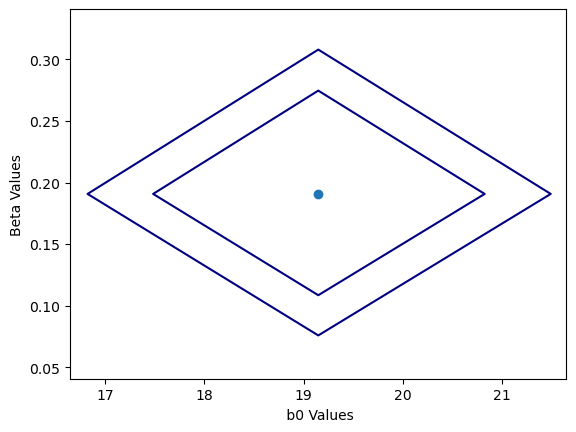

In [60]:
print('B0 Values',b0vals)
print('Beta Values',Bvals)
print('P Values',pvals)
fig, ax = plt.subplots()
ax.set_ylabel("Beta Values")
ax.set_xlabel(" b0 Values")

#ax.set_xlim(res.x[0]-0.5,res.x[0]+0.5)
#ax.set_ylim(0.18,0.20)
ax.set_xlim(res.x[0]-2.5,res.x[0]+2.5)
ax.set_ylim(res.x[1]-0.15,res.x[1]+0.15)
ax.contour(b0vals, Bvals, pvals, levels=[0.05,0.32], colors = "#000080")
ax.plot([res.x[0]],[res.x[1]],"o")

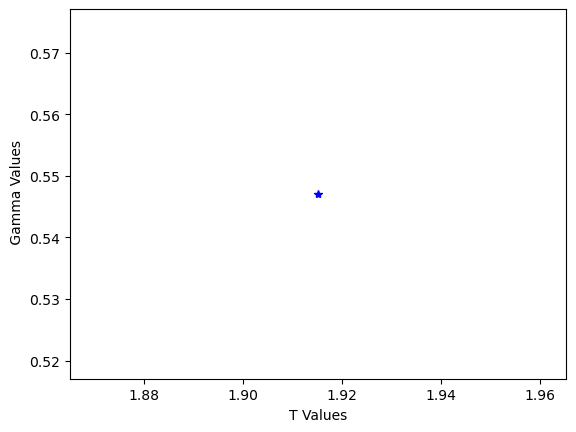

In [61]:
fig, ax = plt.subplots()
ax.set_xlabel("T Values")
ax.set_ylabel(" Gamma Values")
ax.set_xlim(C_pair[0] - 0.05,C_pair[0] + 0.05)
ax.set_ylim(C_pair[1] - 0.03,C_pair[1] + 0.03)
ax.contour(Tvals, Gvals, pvals, levels=[0.05, 0.32], colors = "#000080")
ax.plot([C_pair[0]],[C_pair[1]],"b*")

[-0.02311699  8.          5.27297901] 194.57653640288612
[-0.02311698  8.          5.27297901] 194.57653640302715
[-0.02311699  7.99999999  5.27297901] 194.57653637773356
[-0.02311699  8.          5.27297902] 194.57653642170771
[-0.03721984  5.48474407  3.3908195 ] 190.37740276824522
[-0.03721983  5.48474407  3.3908195 ] 190.37740274723154
[-0.03721984  5.48474408  3.3908195 ] 190.37740276114985
[-0.03721984  5.48474407  3.39081951] 190.377402762046
[0.94306812 5.64235627 3.55031004] 245.99172730404663
[0.94306813 5.64235627 3.55031004] 245.99172825122798
[0.94306812 5.64235628 3.55031004] 245.99172730001072
[0.94306812 5.64235627 3.55031005] 245.991727300507
[-0.02298799  5.48703229  3.39313499] 190.3596966941463
[-0.02298798  5.48703229  3.39313499] 190.35969669456986
[-0.02298799  5.4870323   3.39313499] 190.35969668709657
[-0.02298799  5.48703229  3.393135  ] 190.35969668798768
[-0.02389134  6.06187449  3.82376059] 190.1432277752496
[-0.02389133  6.06187449  3.82376059] 190.1432277

[-0.12716484  5.36586978  4.36422142] 186.55596803068093
[-0.12716485  5.36586979  4.36422142] 186.55596817580744
[-0.12716485  5.36586978  4.36422143] 186.5559681772919
[-0.01268962  6.02958479  4.59073889] 185.26254215979674
[-0.01268961  6.02958479  4.59073889] 185.2625421751445
[-0.01268962  6.0295848   4.59073889] 185.26254215875832
[-0.01268962  6.02958479  4.5907389 ] 185.26254215546885
[-0.02531732  6.27669825  4.6796418 ] 185.2318589988662
[-0.02531731  6.27669825  4.6796418 ] 185.23185899511924
[-0.02531732  6.27669826  4.6796418 ] 185.23185900057945
[-0.02531732  6.27669825  4.67964181] 185.2318589959408
[-0.02302447  6.22105352  4.66986512] 185.2263909254649
[-0.02302446  6.22105352  4.66986512] 185.22639092518457
[-0.02302447  6.22105353  4.66986512] 185.2263909266269
[-0.02302447  6.22105352  4.66986513] 185.2263909222564
[-0.02124949  6.16616359  4.67862185] 185.21857755899973
[-0.02124948  6.16616359  4.67862185] 185.2185775614041
[-0.02124949  6.1661636   4.67862185] 1

[-0.0227121   5.45957514  6.        ] 185.91827779247637
[-0.02271211  5.45957515  6.        ] 185.91827779247643
[-0.02271211  5.45957514  5.99999999] 185.9182777948727
5- parameter Min Liklihood value 176.90880952612162
3-parameter Likelihood Value 185.91827779247643
Chisquare value 9.009468266354816
B0 Values [[16.74870987  0.          0.          0.          0.        ]
 [16.74870987  0.          0.          0.          0.        ]
 [16.74870987  0.          0.          0.          0.        ]
 [16.74870987  0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]
Beta Values [[0.07073621 0.         0.         0.         0.        ]
 [0.13073621 0.         0.         0.         0.        ]
 [0.19073621 0.         0.         0.         0.        ]
 [0.25073621 0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]
P Values [[0.0013575  0.         0.         0.         0.        ]


[-0.02311336  8.          2.7423548 ] 187.16651270405254
[-0.02311337  7.99999999  2.7423548 ] 187.1665127048689
[-0.02311337  8.          2.74235481] 187.1665127031573
[-0.02328534  8.          2.77290217] 187.16548901566102
[-0.02328533  8.          2.77290217] 187.16548901566145
[-0.02328534  7.99999999  2.77290217] 187.16548901648684
[-0.02328534  8.          2.77290218] 187.16548901562507
[-0.02328566  8.          2.77473459] 187.16548566990954
[-0.02328565  8.          2.77473459] 187.1654856699095
[-0.02328566  7.99999999  2.77473459] 187.1654856707203
[-0.02328566  8.          2.7747346 ] 187.1654856699091
[-0.02328562  8.          2.77475807] 187.16548566919812
[-0.02328561  8.          2.77475807] 187.1654856691981
[-0.02328562  7.99999999  2.77475807] 187.16548567000862
[-0.02328562  8.          2.77475808] 187.16548566919798
5- parameter Min Liklihood value 176.90880952612162
3-parameter Likelihood Value 187.16548566919812
Chisquare value 10.256676143076504
B0 Values [[16.7

[-0.02311699  8.          5.27297901] 181.47427781995557
[-0.02311698  8.          5.27297901] 181.4742778192429
[-0.02311699  7.99999999  5.27297901] 181.47427781424872
[-0.02311699  8.          5.27297902] 181.47427782257975
[0.04815045 7.42931481 5.01056136] 181.61168255578698
[0.04815046 7.42931481 5.01056136] 181.6116826626286
[0.04815045 7.42931482 5.01056136] 181.6116825573993
[0.04815045 7.42931481 5.01056137] 181.61168255536222
[3.46627508e-03 7.78713035e+00 5.17509535e+00] 181.39937816708616
[3.46628508e-03 7.78713035e+00 5.17509535e+00] 181.39937820653236
[3.46627508e-03 7.78713036e+00 5.17509535e+00] 181.3993781713325
[3.46627508e-03 7.78713035e+00 5.17509536e+00] 181.3993781686045
[-6.85101324e-03  7.57448230e+00  5.07771413e+00] 181.28322694589963
[-6.85100324e-03  7.57448230e+00  5.07771413e+00] 181.28322696981456
[-6.85101324e-03  7.57448231e+00  5.07771413e+00] 181.28322694861748
[-6.85101324e-03  7.57448230e+00  5.07771414e+00] 181.28322694627983
[-0.02275437  7.27256

...

[-0.02311699  8.          5.27297901] 202.8724245974138
[-0.02311698  8.          5.27297901] 202.87242459842474
[-0.02311699  7.99999999  5.27297901] 202.87242457192127
[-0.02311699  8.          5.27297902] 202.87242469110015
[-0.12421017  5.45074602  0.5       ] 218.57169706806977
[-0.12421016  5.45074602  0.5       ] 218.57169691814204
[-0.12421017  5.45074603  0.5       ] 218.5716970145538
[-0.12421017  5.45074602  0.50000001] 218.5716965958609
[-0.07141876  6.78198028  2.99247554] 190.47379611211713
[-0.07141875  6.78198028  2.99247554] 190.47379604014205
[-0.07141876  6.78198029  2.99247554] 190.47379610309952
[-0.07141876  6.78198028  2.99247555] 190.47379612217338
[1.         6.44816605 1.9083086 ] 253.5000770673358
[0.99999999 6.44816605 1.9083086 ] 253.5000760983382
[1.         6.44816606 1.9083086 ] 253.500077045225
[1.         6.44816605 1.90830861] 253.50007702578316
[-0.02363935  6.76709399  2.94412763] 190.27035417163762
[-0.02363934  6.76709399  2.94412763] 190.27035417

[-0.02311699  8.          5.27297901] 179.770848551409
[-0.02311698  8.          5.27297901] 179.77084855202816
[-0.02311699  7.99999999  5.27297901] 179.77084855392462
[-0.02311699  8.          5.27297902] 179.77084856425307
[-0.08503368  8.          3.98857069] 179.31470349094354
[-0.08503367  8.          3.98857069] 179.31470339865263
[-0.08503368  7.99999999  3.98857069] 179.31470349983164
[-0.08503368  8.          3.9885707 ] 179.3147034887968
[0.06785225 8.         3.60613731] 179.8476663818824
[0.06785226 8.         3.60613731] 179.84766651925614
[0.06785225 7.99999999 3.60613731] 179.847666392635
[0.06785225 8.         3.60613732] 179.84766637392605
[-0.03040667  8.          3.85192507] 179.0759555259611
[-0.03040666  8.          3.85192507] 179.07595551542585
[-0.03040667  7.99999999  3.85192507] 179.07595553551565
[-0.03040667  8.          3.85192508] 179.07595552184543
[-0.02196276  8.          4.19587909] 179.014870755735
[-0.02196275  8.          4.19587909] 179.0148707579

[-0.02311699  8.          5.27297901] 220.3534777296418
[-0.02311698  8.          5.27297901] 220.35347773111303
[-0.02311699  7.99999999  5.27297901] 220.3534776857728
[-0.02311699  8.          5.27297902] 220.35347789776674
[-0.17023912  3.61309775  0.5       ] 235.3607939789457
[-0.17023911  3.61309775  0.5       ] 235.36079376302388
[-0.17023912  3.61309776  0.5       ] 235.36079387268475
[-0.17023912  3.61309775  0.50000001] 235.36079341252196
[-0.09707638  5.79467157  2.87356692] 196.82506292898867
[-0.09707637  5.79467157  2.87356692] 196.8250628190272
[-0.09707638  5.79467158  2.87356692] 196.82506291474047
[-0.09707638  5.79467157  2.87356693] 196.82506294575035
[1.         5.51404265 2.15739979] 258.41206252693325
[0.99999999 5.51404265 2.15739979] 258.412061557851
[1.         5.51404266 2.15739979] 258.4120625005054
[1.         5.51404265 2.1573998 ] 258.41206250440223
[-0.02591042  5.77646753  2.82711006] 196.3737020265696
[-0.02591041  5.77646753  2.82711006] 196.373702022

[-0.02311699  8.          5.27297901] 188.92425955247614
[-0.02311698  8.          5.27297901] 188.9242595538525
[-0.02311699  7.99999999  5.27297901] 188.92425954650082
[-0.02311699  8.          5.27297902] 188.9242595956422
[-0.16075196  7.40246766  0.95637218] 199.17689171532234
[-0.16075195  7.40246766  0.95637218] 199.17689151298316
[-0.16075196  7.40246767  0.95637218] 199.17689168660002
[-0.16075196  7.40246766  0.95637219] 199.17689153689147
[-0.08004868  7.75283515  3.48744637] 184.69864295277821
[-0.08004867  7.75283515  3.48744637] 184.6986428682874
[-0.08004868  7.75283516  3.48744637] 184.698642943626
[-0.08004868  7.75283515  3.48744638] 184.6986429586856
[0.60875967 7.6151173  1.86263758] 214.81518283682598
[0.60875968 7.6151173  1.86263758] 214.81518359948413
[0.60875967 7.61511731 1.86263758] 214.8151828161124
[0.60875967 7.6151173  1.86263759] 214.81518278067827
[-0.02431523  7.741692    3.35597844] 184.41412816153348
[-0.02431522  7.741692    3.35597844] 184.41412816

[-0.02311699  8.          5.27297901] 206.19054743040638
[-0.02311698  8.          5.27297901] 206.19054743254756
[-0.02311699  7.99999999  5.27297901] 206.19054740423545
[-0.02311699  8.          5.27297902] 206.1905475351469
[-0.23723478  5.38290624  0.5       ] 223.04389549507923
[-0.23723477  5.38290624  0.5       ] 223.0438951876616
[-0.23723478  5.38290625  0.5       ] 223.04389543993386
[-0.23723478  5.38290624  0.50000001] 223.0438950156728
[-0.12519029  6.75239044  2.9976252 ] 192.51406736800124
[-0.12519028  6.75239044  2.9976252 ] 192.51406721714395
[-0.12519029  6.75239045  2.9976252 ] 192.51406735805287
[-0.12519029  6.75239044  2.99762521] 192.5140673827129
[1.         5.94514231 1.26373293] 260.75233460153544
[0.99999999 5.94514231 1.26373293] 260.75233363225817
[1.         5.94514232 1.26373293] 260.7523345671703
[1.         5.94514231 1.26373294] 260.7523344887829
[-0.02736142  6.68220483  2.84687317] 191.64759317259544
[-0.02736141  6.68220483  2.84687317] 191.6475931

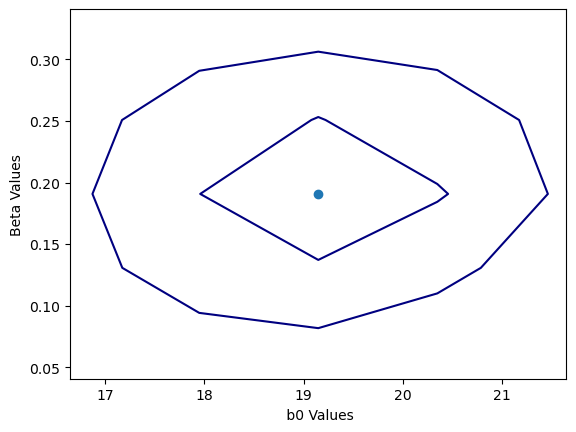

In [62]:
# Part D

def ifun(x,b,t,B0,BE,bi,xi,dbi,dxi):
    bt = B0 * ((np.exp(x)/N0) ** BE)
    bstar = bt * (t[1]/t[2])**(1/t[2])
    p = (t[2] * np.exp(x * t[0]) * ((bstar/b)**t[1]) * np.exp(-(bstar/b)**t[2]) ) / ( bstar * scipy.special.gamma((t[1]-1)/t[2]))
    v = np.exp(- ((b - bi) ** 2) / (2 * (dbi ** 2)) ) 
    v1 = np.exp(- ((x - xi) **2) / (2 * (dxi ** 2)) )
    num = p * v * v1
    return num           
def llfun(t,B0,BE):
    ret = 0
    if(t[0] == 0):
        fact0 = 1/(xmax-xmin)
    else:
        fact0 = t[0]/(np.exp(t[0]*xmax)-np.exp(t[0]*xmin))
    for i in range(len(x)):
        C1 = (2 * np.pi * dx[i] * db1[i])
        fact = fact0 / C1
        b_lim = [max(0, b1[i] - 5 * db1[i]), b1[i] + 5*db1[i]]
        x_lim = [max(xmin, x[i] - 5*dx[i]), min(xmax, x[i] + 5*dx[i])]
        v = scipy.integrate.dblquad(ifun,b_lim[0],b_lim[1],x_lim[0],x_lim[1],args=(t,B0,BE,b1[i],x[i],db1[i],dx[i]))
        if(v[0] > 0): 
            ret -= np.log(fact * v[0])
    print(t,ret)
    return ret

b01 =  res.x[0]
db0 = 4.8
b11 = res.x[1]
db11 = 0.24
N = 4
tv = [1,1]
#t = [α, ϕ, Φ]
p1 = [res.x[2], res.x[3], res.x[4]]

b0vals = np.zeros(( N + 1,N + 1))
Bvals = np.zeros((  N + 1,N + 1))
pvals = np.zeros((  N + 1,N + 1))

bounds0 = scipy.optimize.Bounds()
bounds0.lb = np.array([-1, 2, 0.5])
bounds0.ub = np.array([1, 8, 6])
for i1 in range(N + 1):
    tv[0] = b01 + (db0/N) * (i1 - N/2)
    for i0 in range(N + 1):
        tv[1] = b11  + (db11/N) * (i0 - N/2)
        b0vals[i0,i1] = tv[0]
        Bvals[i0,i1] =  tv[1] 
        resmin = scipy.optimize.minimize(llfun, p1, args = (tv[0],tv[1]), bounds = bounds0)
        chisqq = resmin.fun - res.fun
        pvals[i0,i1] =  1 - scipy.stats.chi2.cdf(chisqq, 2)
        print('5- parameter Min Liklihood value',res.fun)
        print('3-parameter Likelihood Value',resmin.fun)
        print('Chisquare value',chisqq)
        print('B0 Values',b0vals)
        print('Beta Values',Bvals)
        print('P Values',pvals)
        
fig, ax = plt.subplots()
ax.set_ylabel("Beta Values")
ax.set_xlabel(" b0 Values")

#ax.set_xlim(res.x[0]-0.5,res.x[0]+0.5)
#ax.set_ylim(0.18,0.20)
ax.set_xlim(res.x[0]-2.5,res.x[0]+2.5)
ax.set_ylim(res.x[1]-0.15,res.x[1]+0.15)
ax.contour(b0vals, Bvals, pvals, levels=[0.05,0.32], colors = "#000080")
ax.plot([res.x[0]],[res.x[1]],"b*")
        

[[0.23389283 0.23389283 0.23389283 0.23389283 0.23389283]
 [0.40159177 0.40159177 0.40159177 0.40159177 0.40159177]
 [0.54705494 0.54705494 0.54705494 0.54705494 0.54705494]
 [0.67442983 0.67442983 0.67442983 0.67442983 0.67442983]
 [0.78689285 0.78689285 0.78689285 0.78689285 0.78689285]]
[[1.59629952 1.81051594 2.03680641 2.27503082 2.52505906]
 [1.56591502 1.76024488 1.96376184 2.17628359 2.39764221]
 [1.55029891 1.72922753 1.91521587 2.10807374 2.30762725]
 [1.54538683 1.71208193 1.88422045 2.06162218 2.24412334]
 [1.54844917 1.70521918 1.86617294 2.0311493  2.20000257]]
(1.9152158659599539, 0.5470549358761017)


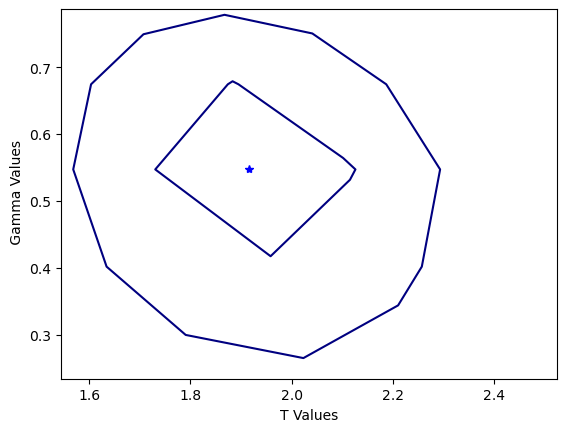

In [64]:
Gvals = np.zeros(( N + 1,N + 1))
Tvals = np.zeros((  N + 1,N + 1))
for i1 in range(N+1):
    for i2 in range (N+1):
        bb = 1 + 1.4*Bvals[i1][i2]
        G = ((3.634 * Bvals[i1][i2]) / bb) 
        T = (( (b0vals[i1][i2] / 13) ** 2) * (bb / 1 + 0.128* Bvals[i1][i2]) ** Bvals[i1][i2] ) ** (1 / bb)
        Gvals[i1][i2] = G 
        Tvals[i1][i2] = T
print(Gvals)
print(Tvals)
print(C_pair)
fig, ax = plt.subplots()
ax.set_xlabel("T Values")
ax.set_ylabel(" Gamma Values")
ax.contour(Tvals, Gvals, pvals, levels=[0.05, 0.32], colors = "#000080")
ax.plot([C_pair[0]],[C_pair[1]],"b*")

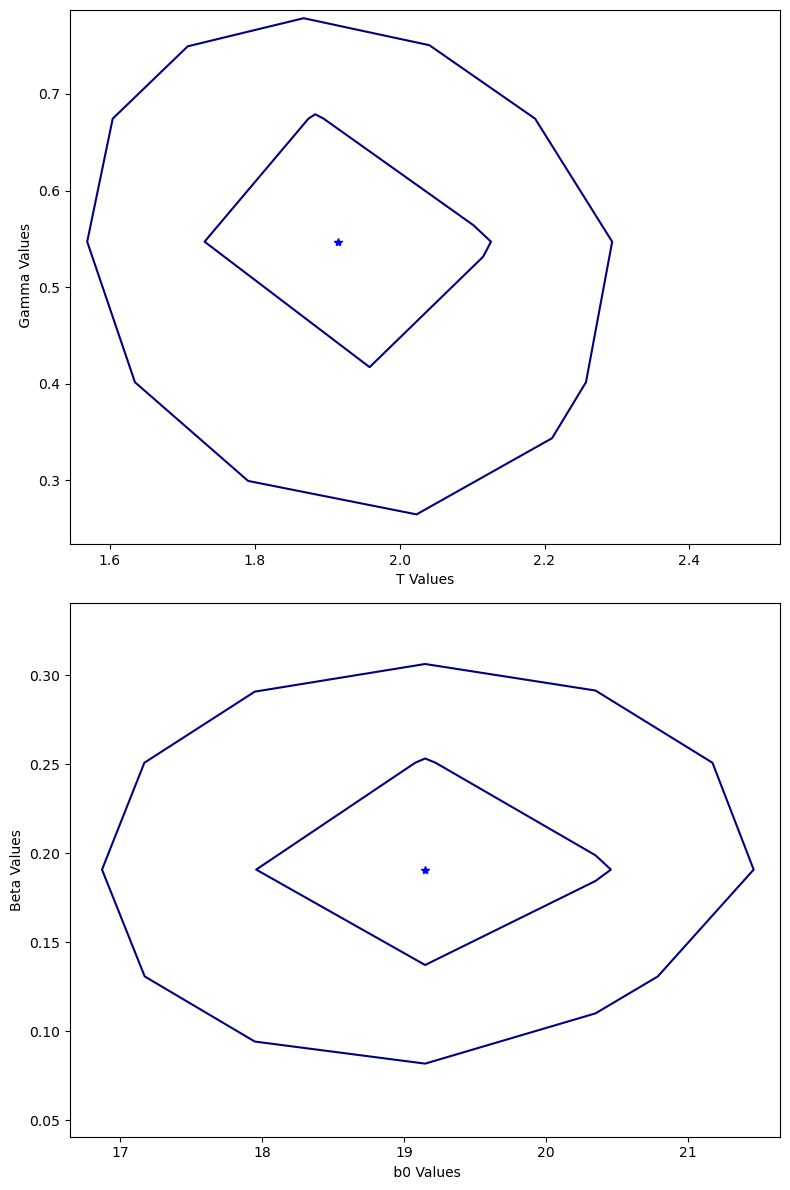

In [69]:
fig, ax = plt.subplots(2,figsize = (8,12))
ax[0].set_xlabel("T Values")
ax[0].set_ylabel(" Gamma Values")
ax[0].contour(Tvals, Gvals, pvals, levels=[0.05, 0.32], colors = "#000080")
ax[0].plot([C_pair[0]],[C_pair[1]],"b*")

ax[1].set_ylabel("Beta Values")
ax[1].set_xlabel(" b0 Values")
ax[1].set_xlim(res.x[0]-2.5,res.x[0]+2.5)
ax[1].set_ylim(res.x[1]-0.15,res.x[1]+0.15)
ax[1].contour(b0vals, Bvals, pvals, levels=[0.05,0.32], colors = "#000080")
ax[1].plot([res.x[0]],[res.x[1]],"b*")
fig.tight_layout()
plt.savefig("ASTR Part D", dpi=300)

227
202
202
202


Text(0, 0.5, 'Doppler b parameter (km/s)')

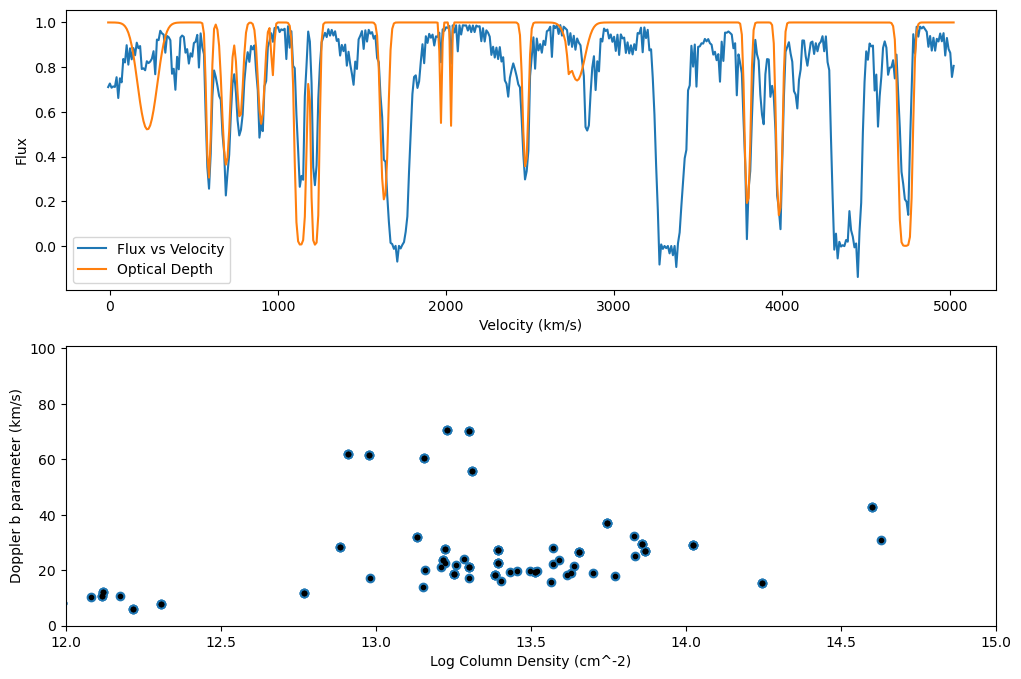

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import stats
import math

filename = "los-Copy1.00000.fHI"
vel1,flux1 = np.loadtxt(filename,delimiter = ',', unpack = True, skiprows = 2)
vel = []
flux = []
for i in range(504):
    vel.append(vel1[i])
    flux.append(flux1[i])
fig, axs = plt.subplots(2,figsize = (12,8))
axs[0].plot(vel, flux, label = 'Flux vs Velocity')
axs[0].set_ylabel('Flux')
axs[0].set_xlabel('Velocity (km/s)')

filename1 = "los.00000 (1).bN"
WL, ro, b, dWL, dro, db, chisq = np.loadtxt(filename1, unpack = True)
filename2 = "los-Copy1.00001.bN"
WL2, ro2, b2, dWL2, dro2, db2, chisq2 = np.loadtxt(filename2, unpack = True)
filename3 = "los-Copy1.00001.bN"
WL3, ro3, b3, dWL3, dro3, db3, chisq3 = np.loadtxt(filename3, unpack = True)
filename4 = "los-Copy1.00001.bN"
WL4, ro4, b4, dWL4, dro4, db4, chisq4 = np.loadtxt(filename4, unpack = True)

WL1 = []
ro1 = []
dWL1 = []
dro1 = []
db1 = []
b1 = []
chisq1 = []

for i in range(len(chisq)):
    if 0.1 < chisq[i] < 3  and 8 < b[i] < 100 and 12 < ro[i] < 15 and np.isfinite(chisq[i]) and np.isfinite(db[i]) and np.isfinite(dro[i]) and np.isfinite(ro[i]) and np.isfinite(b[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])   
for i in range(len(chisq2)):
    if 0.1 < chisq2[i] < 3  and 8 < b2[i] < 100 and 12 < ro2[i] < 15 and np.isfinite(chisq2[i]) and np.isfinite(db2[i]) and np.isfinite(dro2[i]) and np.isfinite(ro2[i]) and np.isfinite(b2[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])
for i in range(len(chisq3)):
    if 0.1 < chisq3[i] < 3  and 8 < b3[i] < 100 and 12 < ro3[i] < 15 and np.isfinite(chisq3[i]) and np.isfinite(db3[i]) and np.isfinite(dro3[i]) and np.isfinite(ro3[i]) and np.isfinite(b3[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])
for i in range(len(chisq4)):
    if 0.1 < chisq4[i] < 3  and 8 < b4[i] < 100 and 12 < ro4[i] < 15 and np.isfinite(chisq4[i]) and np.isfinite(db4[i]) and np.isfinite(dro4[i]) and np.isfinite(ro4[i]) and np.isfinite(b4[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])
        
print(len(chisq))
print(len(chisq2))
print(len(chisq3))
print(len(chisq4))
Cm = 4.5e-18
c = 3e5
vi_lst = []
for i in WL1:
    vi = 3e5 * ((i / (4*1216)) - 1)
    vi_lst.append(vi)   
def tfit(num):
    sum1 = 0
    for i in range(len(WL1)):
        A = (10**ro1[i] * c) / (b1[i] * np.sqrt(np.pi))
        B = ((num - vi_lst[i]) ** 2) / (b1[i] ** 2)
        sum1 += A * np.exp(-B)
    val = Cm * sum1
    return val  

axs[0].plot(vel,np.exp(-tfit(vel)), label = 'Optical Depth')
axs[0].legend()

axs[1].errorbar(ro1, b1, dro1, fmt = 'k.', label = 'Errors',capsize = 0)
axs[1].plot(ro1, b1, 'o')
axs[1].set_xlim(12,15)
axs[1].set_ylim(0,101)
axs[1].set_xlabel('Log Column Density (cm^-2)')
axs[1].set_ylabel('Doppler b parameter (km/s)')
